# acc_total — High-Intensity Acceleration Count Prediction

## Overview

**Target:** `acc_total` — daily sum of high-intensity accelerations (Band 7+, effort count).

| Item | Detail |
|---|---|
| **Loss** | Tweedie (`variance_power` 1.1–1.9) — natural fit for count data with zeros |
| **Features** | 17 base features + 35 player one-hots = 52 total |
| **Tuning** | `RandomizedSearchCV` (n\_iter=100, 5-fold CV) + elastic net (L1+L2) + early stopping |
| **Split** | Random 80/20, no target transform (Tweedie handles skew internally) |
| **Interpretability** | SHAP `TreeExplainer` |
| **Test results** | MAE ≈ 3.63 · RMSE ≈ 5.00 · R² ≈ 0.38 |

## Setup

Imports, constants, and target declaration.

In [1]:
"""
acc_total: FINAL with Tweedie loss.
- 17 base features + 35 player_id one-hots = 52 features
- Tweedie loss with tunable variance_power (1.1-1.9) — natural fit for count
  data with zeros (3.1% zero rows in target)
- XGBoost + RandomizedSearchCV + elastic net (L1+L2) + early stopping
- Random 80/20 split, no target transform (Tweedie handles skew natively)
- SHAP for interpretability
- Learning curve (bias-variance diagnostic)

Test results: MAE ~3.63, RMSE ~5.00, R² ~0.38
"""

import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
# ---------------------------------------------------------------------------
# Repo-root resolver — works locally (notebooks/) and in Databricks (repo root)
# ---------------------------------------------------------------------------
import subprocess as _sp
from pathlib import Path as _Path

def _repo_root():
    try:
        return _Path(_sp.run(
            ["git", "rev-parse", "--show-toplevel"],
            capture_output=True, text=True, check=True,
        ).stdout.strip())
    except Exception:
        p = _Path.cwd()
        while p != p.parent:
            if (p / ".git").exists() or (p / "pyproject.toml").exists() or (p / "AGENTS.md").exists():
                return p
            p = p.parent
        return _Path.cwd()

REPO_ROOT  = _repo_root()
DATA_DIR   = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
REPORTS_DIR = REPO_ROOT / "reports"
TARGET = "acc_total"
FIGURES_DIR = REPORTS_DIR / "figures" / TARGET
MODEL_EXPERIMENTS_DIR = MODELS_DIR / "notebook_experiments" / TARGET
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------------------------------------------------

warnings.filterwarnings("ignore")

## 1. Load Preprocessed Data

Reads the feature-engineered dataset produced by `data_pipeline.ipynb`. Player identity one-hots are added here; the other two targets are dropped.

In [2]:
model_data = pd.read_parquet(DATA_DIR / "processed" / "model_data.parquet")
print(f"Loaded model_data: {model_data.shape}  |  {model_data.columns.tolist()}")

# Player identity one-hot encoding
player_dummies = pd.get_dummies(model_data["player_id"], prefix="pid", dtype=int)
model_data = pd.concat([model_data, player_dummies], axis=1)
print(f"Added {player_dummies.shape[1]} player_id one-hot columns")

# Keep only this target; drop the other two
DROP_COLS = ["player_id", "total_distance", "vel_total"]
model_data = model_data.drop(columns=[c for c in DROP_COLS if c in model_data.columns])
feature_cols = [c for c in model_data.columns if c != TARGET]

assert model_data.isna().sum().sum() == 0, "Unexpected NaNs in model_data"
print(f"Ready: {model_data.shape}  |  {len(feature_cols)} features")


Loaded model_data: (2103, 21)  |  ['player_id', 'total_distance', 'acc_total', 'vel_total', 'height', 'weight', 'age', 'has_G', 'has_TAC', 'has_BP', 'has_TEC', 'has_MATCH', 'n_session_types', 'pos_central_back', 'pos_central_midfielder', 'pos_forward', 'pos_full_back', 'pos_winger', 'days_since_start', 'days_since_last_activity', 'days_since_last_match']
Added 28 player_id one-hot columns
Ready: (2103, 46)  |  45 features


## 2. Target Distribution Diagnostic

In [3]:
y_diag = model_data[TARGET]
print(f"\nTarget: {TARGET}")
print(f"  Range: [{y_diag.min():.0f}, {y_diag.max():.0f}]")
print(f"  Skewness: {y_diag.skew():.3f}")
print(f"  Zeros: {(y_diag == 0).sum()} ({(y_diag == 0).mean() * 100:.1f}%)")


Target: acc_total
  Range: [0, 48]
  Skewness: 1.548
  Zeros: 66 (3.1%)


## 3. Train / Test Split

In [4]:
X = model_data[feature_cols]
y = model_data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)
print(f"\nTrain: {len(X_train)}  Test: {len(X_test)}")


Train: 1682  Test: 421


## 4. Model Pipelines — Tweedie

In [5]:
def build_search_pipeline():
    """Used for hyperparameter tuning. Includes early stopping."""
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("xgb", XGBRegressor(
            objective="reg:tweedie",   # Tweedie handles count-like with zeros
            tree_method="hist",
            random_state=42, n_jobs=-1, verbosity=0,
            early_stopping_rounds=50,
        )),
    ])


def build_lc_pipeline(params):
    """Used only for learning curve diagnostic. NO early stopping
    (sklearn's learning_curve doesn't support eval_set)."""
    return Pipeline([
        ("scaler", MinMaxScaler()),
        ("xgb", XGBRegressor(
            **params,
            objective="reg:tweedie",
            tree_method="hist",
            random_state=42, n_jobs=-1, verbosity=0,
        )),
    ])


def evaluate(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }

## 5. Hyperparameter Tuning (RandomizedSearchCV)

In [6]:
PARAM_DIST = {
    "xgb__n_estimators":          [200, 400, 600, 800, 1000, 1200, 1600, 2000],
    "xgb__learning_rate":         [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "xgb__max_depth":             [3, 4, 5, 6, 7, 8],
    "xgb__min_child_weight":      [1, 2, 3, 5, 7, 10],
    "xgb__subsample":             [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree":      [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bylevel":     [0.6, 0.8, 1.0],
    "xgb__gamma":                 [0, 0.1, 0.3, 0.5, 1, 3, 5, 10],
    # Elastic net
    "xgb__reg_alpha":             [0, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50],
    "xgb__reg_lambda":            [0.1, 0.5, 1, 3, 5, 10, 25, 50, 100],
    # Tweedie-specific
    "xgb__tweedie_variance_power": [1.1, 1.3, 1.5, 1.7, 1.9],
}
N_ITER = 100

print(f"\n--- Tuning {TARGET} (Tweedie loss, elastic net, n_iter={N_ITER}) ---")

# Early-stopping holdout
n_train = len(X_train)
val_size = max(int(n_train * 0.15), 50)
rng = np.random.default_rng(42)
val_idx = rng.choice(n_train, size=val_size, replace=False)
train_idx_es = np.setdiff1d(np.arange(n_train), val_idx)

es_scaler = MinMaxScaler().fit(X_train.iloc[train_idx_es])
X_es_val = es_scaler.transform(X_train.iloc[val_idx])
y_es_val = y_train.iloc[val_idx].values

fit_params = {"xgb__eval_set": [(X_es_val, y_es_val)], "xgb__verbose": False}

search = RandomizedSearchCV(
    estimator=build_search_pipeline(),
    param_distributions=PARAM_DIST,
    n_iter=N_ITER,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="neg_mean_absolute_error",
    n_jobs=-1, random_state=42, verbose=1, return_train_score=False,
)
search.fit(X_train, y_train, **fit_params)
best = search.best_estimator_

# Predictions in original units (Tweedie outputs to original scale).
# Clip negative at 0 — acc_total is bounded at 0.
y_train_pred = np.clip(best.predict(X_train), 0, None)
y_test_pred = np.clip(best.predict(X_test), 0, None)

train_metrics = evaluate(y_train, y_train_pred)
test_metrics  = evaluate(y_test,  y_test_pred)

print(f"\n  Best CV MAE: {-search.best_score_:.4f}")
print(f"  Best params: " + ", ".join(f"{k.replace('xgb__','')}={v}" for k, v in search.best_params_.items()))


--- Tuning acc_total (Tweedie loss, elastic net, n_iter=100) ---
Fitting 5 folds for each of 100 candidates, totalling 500 fits

  Best CV MAE: 3.5986
  Best params: tweedie_variance_power=1.9, subsample=0.8, reg_lambda=5, reg_alpha=1, n_estimators=1600, min_child_weight=10, max_depth=4, learning_rate=0.005, gamma=0.3, colsample_bytree=0.7, colsample_bylevel=0.6


## 6. SHAP Interpretability

In [7]:
print("\n--- SHAP analysis ---")
scaler = best.named_steps["scaler"]
xgb_model = best.named_steps["xgb"]
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)

pid_cols = [c for c in feature_cols if c.startswith("pid_")]
non_pid_cols = [c for c in feature_cols if not c.startswith("pid_")]
print("\nNon-player_id features (top 15):")
for feat, val in shap_importance[non_pid_cols].head(15).items():
    print(f"  {feat:30s} {val:>10.4f}")
print(f"\n  Player_id share of total: {shap_importance[pid_cols].sum() / shap_importance.sum() * 100:.1f}%")


--- SHAP analysis ---

Non-player_id features (top 15):
  height                             0.0607
  weight                             0.0133
  age                                0.0187
  has_G                              0.1465
  has_TAC                            0.0087
  has_BP                             0.0280
  has_TEC                            0.0150
  has_MATCH                          0.0112
  n_session_types                    0.2011
  pos_central_back                   0.0391
  pos_central_midfielder             0.0243
  pos_forward                        0.0100
  pos_full_back                      0.0248
  pos_winger                         0.0005
  days_since_start                   0.0493

  Player_id share of total: 3.2%


## 7. Learning Curve — Bias-Variance Diagnostic


--- Generating learning curve ---


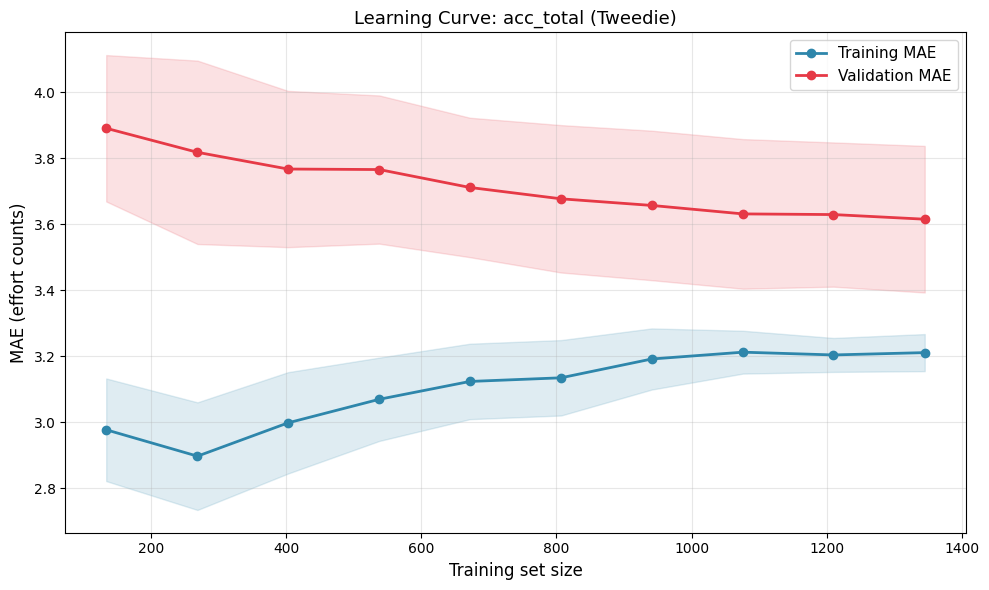

  Train MAE: 3.2111
  Val MAE:   3.6151
  Gap:       0.4040
  Saved: reports/figures/acc_total/learning_curve.png


In [8]:
print("\n--- Generating learning curve ---")
best_params_only = {k.replace("xgb__", ""): v for k, v in search.best_params_.items()}
lc_pipeline = build_lc_pipeline(best_params_only)

train_sizes_pct = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_pipeline, X_train, y_train,
    train_sizes=train_sizes_pct, cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1, shuffle=True, random_state=42,
)

train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)
train_mae_std = train_scores.std(axis=1)
val_mae_std   = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mae, "o-", color="#2E86AB", label="Training MAE", linewidth=2)
plt.plot(train_sizes_abs, val_mae,   "o-", color="#E63946", label="Validation MAE", linewidth=2)
plt.fill_between(train_sizes_abs, train_mae - train_mae_std, train_mae + train_mae_std, alpha=0.15, color="#2E86AB")
plt.fill_between(train_sizes_abs, val_mae - val_mae_std, val_mae + val_mae_std, alpha=0.15, color="#E63946")
plt.xlabel("Training set size", fontsize=12)
plt.ylabel("MAE (effort counts)", fontsize=12)
plt.title(f"Learning Curve: {TARGET} (Tweedie)", fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(str(FIGURES_DIR / "learning_curve.png"), dpi=120, bbox_inches="tight")
plt.show()

final_train = train_mae[-1]
final_val = val_mae[-1]
gap = final_val - final_train
print(f"  Train MAE: {final_train:.4f}")
print(f"  Val MAE:   {final_val:.4f}")
print(f"  Gap:       {gap:.4f}")
print(f"  Saved: {FIGURES_DIR.relative_to(REPO_ROOT) / 'learning_curve.png'}")

## 8. Model Persistence

In [9]:
OUT = MODEL_EXPERIMENTS_DIR
OUT.mkdir(parents=True, exist_ok=True)
with open(OUT / "pipeline.pkl", "wb") as f:
    pickle.dump(best, f)
with open(OUT / "feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

# Tweedie has no transform; predictions are in original units.
# Save explicit metadata so dashboard knows there's no expm1 step.
with open(OUT / "transform.pkl", "wb") as f:
    pickle.dump({"type": "none", "loss": "tweedie"}, f)
print(f"\nSaved: {OUT.relative_to(REPO_ROOT) / 'pipeline.pkl'} (Tweedie)")
print(f"Saved: {OUT.relative_to(REPO_ROOT) / 'transform.pkl'} (no inverse transform needed)")


Saved: models/notebook_experiments/acc_total/pipeline.pkl (Tweedie)
Saved: models/notebook_experiments/acc_total/transform.pkl (no inverse transform needed)


## 9. Final Metrics

In [10]:
print("\n" + "=" * 70)
print(f"{'TARGET':<20}  {'SPLIT':<6}  {'MAE':>10}  {'RMSE':>10}  {'R2':>8}")
print("=" * 70)
for split, res in [("Train", train_metrics), ("Test", test_metrics)]:
    print(f"{TARGET:<20}  {split:<6}  {res['MAE']:>10.4f}  {res['RMSE']:>10.4f}  {res['R2']:>8.4f}")


TARGET                SPLIT          MAE        RMSE        R2
acc_total             Train       3.2452      4.5589    0.5326
acc_total             Test        3.6298      5.0073    0.3791
